# Sprint 3 — Mecanismos de Atenção

**Capítulo 3 — *Coding Attention Mechanisms*** · RASCHKA, S. *Build a Large Language Model
(From Scratch)*, Manning.

Este notebook percorre, passo a passo, os quatro mecanismos de atenção implementados na Sprint 3.
A lógica definitiva mora em [`src/attention.py`](../src/attention.py); aqui ela é **importada**, não
reescrita — o notebook serve para inspecionar tensores intermediários e ver o comportamento de cada
etapa.

## Roteiro

| Seção | Assunto | Referência no livro |
|---|---|---|
| 1 | Por que atenção | 3.1 e 3.2 |
| 2 | Self-attention sem pesos treináveis | 3.3 |
| 3 | Scaled dot-product attention | 3.4 |
| 4 | Causal attention e dropout | 3.5 |
| 5 | Multi-head attention | 3.6 |
| 6 | Atenção sobre dados reais da Sprint 2 | — |
| 7 | Exercícios 3.1, 3.2 e 3.3 | — |

Os experimentos completos estão em
[`experiments/sprint03-atencao/`](../experiments/sprint03-atencao/) e a análise dos resultados em
[`reports/sprint03-relatorio.md`](../reports/sprint03-relatorio.md).

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))

import torch

from attention import (
    atencao_simples,
    mascara_causal,
    scaled_dot_product_attention,
    SelfAttentionV1,
    SelfAttentionV2,
    CausalAttention,
    MultiHeadAttentionWrapper,
    MultiHeadAttention,
)

torch.set_printoptions(precision=4, sci_mode=False)
print("torch", torch.__version__)

torch 2.13.0+cu126


---
## 1. Por que atenção (seções 3.1 e 3.2)

Antes do Transformer, tradução automática usava RNNs encoder-decoder. O encoder lia a frase inteira e
comprimia tudo em **um único estado oculto**, que o decoder recebia para começar a gerar. O problema
é estrutural: o decoder não tem acesso aos estados anteriores do encoder, então depende inteiramente
daquele vetor final. Em frases longas, com dependências distantes, informação se perde.

A **atenção** resolve isso deixando cada posição acessar diretamente todas as outras, com pesos que
dizem o quanto cada uma importa. A **self-attention** aplica essa ideia dentro de uma única
sequência: cada token olha todos os tokens da mesma frase — inclusive ele próprio — e constrói sua
representação a partir disso.

---
## 2. Self-attention sem pesos treináveis (seção 3.3)

O livro começa pela versão mais simples possível: sem nenhuma matriz treinável, o próprio embedding
do token faz os três papéis (query, key e value).

Usamos a frase *"Your journey starts with one step"*, já embutida em 3 dimensões (p. 71).

In [2]:
entradas = torch.tensor([
    [0.43, 0.15, 0.89],  # Your     x^1
    [0.55, 0.87, 0.66],  # journey  x^2
    [0.57, 0.85, 0.64],  # starts   x^3
    [0.22, 0.58, 0.33],  # with     x^4
    [0.77, 0.25, 0.10],  # one      x^5
    [0.05, 0.80, 0.55],  # step     x^6
])
tokens = ["Your", "journey", "starts", "with", "one", "step"]
entradas.shape

torch.Size([6, 3])

### Passo 1 — scores de atenção

O score entre dois tokens é o produto escalar dos seus embeddings. Tomando `x^2` ("journey") como
query:

In [3]:
query = entradas[1]
scores_2 = entradas @ query          # equivale ao laço com torch.dot
print("scores de x^2:", scores_2)
print("livro (p. 72): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])")

scores de x^2: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
livro (p. 72): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### Passo 2 — normalização com softmax

Os scores viram pesos que somam 1. Poderíamos dividir pela soma, mas o softmax é preferido: garante
pesos positivos e tem propriedades de gradiente melhores.

In [4]:
pesos_2 = torch.softmax(scores_2, dim=0)
print("pesos de x^2:", pesos_2)
print("soma        :", pesos_2.sum())

pesos de x^2: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
soma        : tensor(1.)


### Passo 3 — vetor de contexto

O vetor de contexto é a soma dos embeddings de entrada, ponderada pelos pesos.

In [5]:
contexto_2 = pesos_2 @ entradas
print("z^2:", contexto_2)
print("livro (p. 75): tensor([0.4419, 0.6515, 0.5683])")

z^2: tensor([0.4419, 0.6515, 0.5683])
livro (p. 75): tensor([0.4419, 0.6515, 0.5683])


### Tudo de uma vez

Os três passos para todos os tokens simultaneamente — é o que `atencao_simples` faz. Os laços
aninhados viram duas multiplicações de matrizes.

In [6]:
contexto, pesos = atencao_simples(entradas)
print("pesos de atenção (6 x 6):")
print(pesos)
print("\nvetores de contexto (6 x 3):")
print(contexto)
print("\nlinha 2 confere com z^2 calculado acima:", torch.allclose(contexto[1], contexto_2))

pesos de atenção (6 x 6):
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

vetores de contexto (6 x 3):
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

linha 2 confere com z^2 calculado acima: True


**Observação importante.** Esta matriz de pesos é **simétrica**: sem `Wq` e `Wk` distintos, o score
de *A* para *B* é necessariamente igual ao de *B* para *A*. Na linguagem isso raramente é verdade —
um adjetivo depende fortemente do substantivo que qualifica, sem que a recíproca valha na mesma
medida. É a primeira limitação que os pesos treináveis removem.

In [7]:
scores_completos = entradas @ entradas.T
print("a matriz de scores é simétrica:", torch.allclose(scores_completos, scores_completos.T))

a matriz de scores é simétrica: True


---
## 3. Scaled dot-product attention (seção 3.4)

Agora entram as três matrizes treináveis. Cada embedding é projetado em três papéis diferentes:

| Papel | Símbolo | O que representa |
|---|---|---|
| **query** | `q = x · Wq` | o que o token *procura* |
| **key** | `k = x · Wk` | o que o token *oferece* para ser encontrado |
| **value** | `v = x · Wv` | o conteúdo que entra no vetor de contexto |

A fórmula completa é:

$$\text{Atenção}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

In [8]:
torch.manual_seed(123)
sa_v1 = SelfAttentionV1(d_in=3, d_out=2)

contexto, pesos = sa_v1(entradas, return_attn_weights=True)
print("saída da SelfAttentionV1:")
print(contexto)
print("\nlivro (p. 87): primeira linha [0.2996, 0.8053], segunda [0.3061, 0.8210]")

saída da SelfAttentionV1:
tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

livro (p. 87): primeira linha [0.2996, 0.8053], segunda [0.3061, 0.8210]


### Por que dividir por √d_k

O produto escalar de dois vetores de dimensão `d_k` cresce, em média, com `√d_k`. Scores grandes
empurram o softmax para um comportamento de **função degrau**: um peso perto de 1, todos os outros
perto de 0. Nessa região a derivada do softmax é quase nula — o gradiente desaparece e o treinamento
estagna.

A célula abaixo mostra o efeito com `d_k = 512`:

In [9]:
torch.manual_seed(123)
q = torch.randn(1, 512)
k = torch.randn(64, 512)
v = torch.randn(64, 8)

_, com_escala = scaled_dot_product_attention(q, k, v, scale=True)
_, sem_escala = scaled_dot_product_attention(q, k, v, scale=False)

def sensibilidade(p):
    "Traço da jacobiana do softmax: quanto gradiente ele deixa passar."
    return float((p * (1 - p)).sum())

print(f"com escala — peso máximo {com_escala.max():.4f} | sensibilidade {sensibilidade(com_escala):.4f}")
print(f"sem escala — peso máximo {sem_escala.max():.4f} | sensibilidade {sensibilidade(sem_escala):.4f}")

com escala — peso máximo 0.1831 | sensibilidade 0.9477
sem escala — peso máximo 1.0000 | sensibilidade 0.0000


Sem a escala, quase toda a massa vai para um único token e o softmax praticamente não deixa gradiente
passar. É esse detalhe que dá nome ao mecanismo: *scaled* dot-product attention.

### `SelfAttentionV1` e `SelfAttentionV2`

As duas classes são matematicamente idênticas — `nn.Linear` sem bias *é* uma multiplicação de
matrizes. A diferença está só na inicialização dos pesos, e é por isso que os números saem
diferentes a partir da mesma semente.

In [10]:
torch.manual_seed(789)
sa_v2 = SelfAttentionV2(d_in=3, d_out=2)
print("saída da SelfAttentionV2:")
print(sa_v2(entradas))
print("\nlivro (p. 89): primeira linha [-0.0739, 0.0713]")

saída da SelfAttentionV2:
tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

livro (p. 89): primeira linha [-0.0739, 0.0713]


---
## 4. Causal attention (seção 3.5)

Um LLM é treinado para prever o próximo token. Se, ao calcular o contexto da posição *i*, ele pudesse
ver as posições *i+1* em diante, aprenderia a **copiar a resposta** em vez de prevê-la — e falharia
na geração, quando o futuro ainda não existe.

A máscara causal zera os pesos acima da diagonal. O livro mostra duas formas de fazer isso.

In [11]:
queries = sa_v2.W_query(entradas)
keys = sa_v2.W_key(entradas)
scores = queries @ keys.T / keys.shape[-1] ** 0.5

# Forma 1 (figura 3.20): softmax, zerar acima da diagonal, renormalizar.
forma_1 = torch.softmax(scores, dim=-1) * torch.tril(torch.ones(6, 6))
forma_1 = forma_1 / forma_1.sum(dim=-1, keepdim=True)

# Forma 2 (figura 3.21): preencher com -inf antes do softmax.
forma_2 = torch.softmax(scores.masked_fill(mascara_causal(6), -torch.inf), dim=-1)

print(forma_2)
print("\nas duas formas coincidem:", torch.allclose(forma_1, forma_2, atol=1e-6))
print("livro (p. 93): linha 2 = [0.5517, 0.4483, 0, 0, 0, 0]")

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

as duas formas coincidem: True
livro (p. 93): linha 2 = [0.5517, 0.4483, 0, 0, 0, 0]


A forma 2 é preferida por um motivo simples: `e^{-∞} = 0`, então o softmax já atribui peso zero às
posições escondidas **e** renormaliza as restantes, em um passo só.

### A classe `CausalAttention`

Aceita lotes 3D (o formato que o DataLoader da Sprint 2 produz) e acrescenta dropout sobre os pesos.
A máscara é guardada com `register_buffer`: é estado do módulo, acompanha o `.to(device)`, mas não é
parâmetro treinável.

In [12]:
lote = torch.stack((entradas, entradas), dim=0)   # (2, 6, 3)

torch.manual_seed(123)
ca = CausalAttention(d_in=3, d_out=2, context_length=6, dropout=0.0).eval()
contexto, pesos = ca(lote, return_attn_weights=True)

print("formato do contexto:", tuple(contexto.shape))
print("máscara é buffer, não parâmetro:", "mask" in dict(ca.named_buffers()))
print("\npesos acima da diagonal, máximo:", float(pesos[0].triu(diagonal=1).max()))
print("soma de cada linha            :", pesos[0].sum(dim=-1))

formato do contexto: (2, 6, 2)
máscara é buffer, não parâmetro: True

pesos acima da diagonal, máximo: 0.0
soma de cada linha            : tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


C:\Users\Razonet\AppData\Local\Temp\ipykernel_14992\300410671.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print("\npesos acima da diagonal, máximo:", float(pesos[0].triu(diagonal=1).max()))


### O teste que prova a causalidade

A verificação decisiva não é olhar a matriz: é perturbar um token e ver o que muda. Se a máscara
funciona, nenhum vetor de contexto **anterior** ao token perturbado pode se mover.

In [13]:
alterado = entradas.clone()
alterado[4] = torch.tensor([9.0, -9.0, 9.0])   # perturbação brutal no token 5 ("one")

with torch.no_grad():
    original = ca(entradas.unsqueeze(0))[0]
    perturbado = ca(alterado.unsqueeze(0))[0]

variacao = (original - perturbado).abs().amax(dim=-1)
for i, (tok, v) in enumerate(zip(tokens, variacao)):
    marca = "<- token alterado" if i == 4 else ""
    print(f"  token {i} ({tok:<8}) variação = {float(v):.2e}  {marca}")

  token 0 (Your    ) variação = 0.00e+00  
  token 1 (journey ) variação = 0.00e+00  
  token 2 (starts  ) variação = 0.00e+00  
  token 3 (with    ) variação = 0.00e+00  
  token 4 (one     ) variação = 6.44e+00  <- token alterado
  token 5 (step    ) variação = 7.69e-01  


Variação **exatamente zero** nas posições 0 a 3, diferente de zero a partir da 4. A informação não
vaza do futuro para o passado.

### Dropout sobre os pesos de atenção (seção 3.5.2)

Aplicado depois do softmax: zera uma fração `p` dos pesos e multiplica os sobreviventes por
`1/(1-p)`. O reescalonamento preserva a *esperança* da saída — mas a soma de cada linha deixa de ser
exatamente 1.

In [14]:
torch.manual_seed(123)
ca_drop = CausalAttention(d_in=3, d_out=2, context_length=6, dropout=0.5)
ca_drop.load_state_dict(ca.state_dict())

ca_drop.train()                 # dropout ativo
torch.manual_seed(123)
_, pesos_treino = ca_drop(lote, return_attn_weights=True)
print("modo treino (dropout 0.5):")
print(pesos_treino[0])

ca_drop.eval()                  # dropout desativado
_, pesos_inferencia = ca_drop(lote, return_attn_weights=True)
print("\nmodo inferência — dropout desligado, linhas somam 1:", pesos_inferencia[0].sum(dim=-1))

modo treino (dropout 0.5):
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6380, 0.6816, 0.6804, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5090, 0.5085, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4120, 0.0000, 0.3869, 0.0000, 0.0000],
        [0.0000, 0.3418, 0.3413, 0.3308, 0.3249, 0.0000]],
       grad_fn=<SelectBackward0>)

modo inferência — dropout desligado, linhas somam 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


---
## 5. Multi-head attention (seção 3.6)

Uma única cabeça precisa comprimir todo tipo de dependência em uma só distribuição de atenção. Com
várias cabeças, cada uma compara tokens num subespaço diferente e pode se especializar.

O livro apresenta duas implementações.

### 5.1 Empilhamento (listagem 3.4)

`num_heads` módulos `CausalAttention` independentes, com as saídas concatenadas. A dimensão final é
`d_out × num_heads`.

In [15]:
torch.manual_seed(123)
mhw = MultiHeadAttentionWrapper(
    d_in=3, d_out=2, context_length=6, dropout=0.0, num_heads=2
).eval()

saida = mhw(lote)
print("formato:", tuple(saida.shape), " -> d_out(2) x num_heads(2) = 4")
print(saida[0])
print("\nlivro (p. 103): primeira linha [-0.4519, 0.2216, 0.4772, 0.1063]")

formato: (2, 6, 4)  -> d_out(2) x num_heads(2) = 4
tensor([[-0.4519,  0.2216,  0.4772,  0.1063],
        [-0.5874,  0.0058,  0.5891,  0.3257],
        [-0.6300, -0.0632,  0.6202,  0.3860],
        [-0.5675, -0.0843,  0.5478,  0.3589],
        [-0.5526, -0.0981,  0.5321,  0.3428],
        [-0.5299, -0.1081,  0.5077,  0.3493]], grad_fn=<SelectBackward0>)

livro (p. 103): primeira linha [-0.4519, 0.2216, 0.4772, 0.1063]


### 5.2 Divisão de pesos (listagem 3.5)

Uma única projeção de tamanho `d_out` por papel, fatiada em `num_heads` blocos de
`head_dim = d_out // num_heads` colunas. Matematicamente equivalente, mas troca `3 × num_heads`
multiplicações de matriz por 3.

O caminho dos tensores:

```
(b, n, d_in)
  -> W_q/W_k/W_v      -> (b, n, d_out)
  -> view             -> (b, n, num_heads, head_dim)
  -> transpose(1, 2)  -> (b, num_heads, n, head_dim)     <- cabeças viram dimensão de lote
  -> atenção          -> (b, num_heads, n, head_dim)
  -> transpose(1, 2)  -> (b, n, num_heads, head_dim)
  -> view             -> (b, n, d_out)
  -> out_proj         -> (b, n, d_out)
```

In [16]:
torch.manual_seed(123)
mha = MultiHeadAttention(
    d_in=3, d_out=2, context_length=6, dropout=0.0, num_heads=2
).eval()

saida = mha(lote)
print("formato:", tuple(saida.shape), " -> aqui d_out já é a dimensão TOTAL")
print(saida[0])
print("\nlivro (p. 109): primeira linha [0.3190, 0.4858]")

formato: (2, 6, 2)  -> aqui d_out já é a dimensão TOTAL
tensor([[0.3190, 0.4858],
        [0.2943, 0.3897],
        [0.2856, 0.3593],
        [0.2693, 0.3873],
        [0.2639, 0.3928],
        [0.2575, 0.4028]], grad_fn=<SelectBackward0>)

livro (p. 109): primeira linha [0.3190, 0.4858]


### As duas implementações são a mesma operação

Copiando as matrizes das cabeças do wrapper para os blocos correspondentes da `MultiHeadAttention` e
anulando a `out_proj` (que só a segunda possui), as saídas coincidem.

In [17]:
torch.manual_seed(123)
ref = MultiHeadAttentionWrapper(3, 2, 6, 0.0, num_heads=2).eval()
equiv = MultiHeadAttention(3, 4, 6, 0.0, num_heads=2).eval()

with torch.no_grad():
    for nome in ("W_query", "W_key", "W_value"):
        blocos = [getattr(h, nome).weight for h in ref.heads]
        getattr(equiv, nome).weight.copy_(torch.cat(blocos, dim=0))
    equiv.out_proj.weight.copy_(torch.eye(4))
    equiv.out_proj.bias.zero_()

print("empilhamento == divisão de pesos:", torch.allclose(equiv(lote), ref(lote), atol=1e-6))

empilhamento == divisão de pesos:

 True


### O que muda com o número de cabeças

Com `d_out` fixo, acrescentar cabeças **não** altera a contagem de parâmetros: as mesmas matrizes
`d_out × d_out` são apenas lidas em blocos menores. O que muda é `head_dim` e o número de matrizes
de atenção calculadas.

In [18]:
print(f"{'num_heads':>10} {'head_dim':>9} {'parâmetros':>12}")
for h in (1, 2, 4, 8, 16):
    torch.manual_seed(123)
    m = MultiHeadAttention(d_in=64, d_out=64, context_length=32, dropout=0.0, num_heads=h)
    print(f"{h:>10} {m.head_dim:>9} {sum(p.numel() for p in m.parameters()):>12,}")

 num_heads  head_dim   parâmetros
         1        64       16,448
         2        32       16,448
         4        16       16,448
         8         8       16,448
        16         4       16,448


---
## 6. Atenção sobre os dados reais da Sprint 2

Até aqui usamos o exemplo de brinquedo do livro. O módulo
[`src/entradas_atencao.py`](../src/entradas_atencao.py) refaz o pipeline da Sprint 2 — tokenização
BPE com `tiktoken`, janela deslizante, embeddings de token e embeddings posicionais — e entrega
tensores prontos a partir de `the-verdict.txt`.

In [19]:
from entradas_atencao import lote_de_embeddings

dados = lote_de_embeddings(d_in=64, max_length=16, batch_size=2)
print("embeddings:", tuple(dados["embeddings"].shape), " (batch, tokens, d_in)")
print("token ids :", tuple(dados["token_ids"].shape))
print("tokens    :", dados["tokens"])

embeddings: (2, 16, 64)  (batch, tokens, d_in)
token ids : (2, 16)
tokens    : ['I', 'H', 'AD', 'always', 'thought', 'Jack', 'G', 'is', 'burn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a']


In [20]:
torch.manual_seed(123)
mha_real = MultiHeadAttention(
    d_in=64, d_out=64, context_length=16, dropout=0.0, num_heads=4
).eval()

contexto, pesos = mha_real(dados["embeddings"], return_attn_weights=True)
print("vetores de contexto:", tuple(contexto.shape))
print("pesos de atenção   :", tuple(pesos.shape), " (batch, cabeças, tokens, tokens)")
print("\ntodas as cabeças respeitam a máscara:", bool((pesos.triu(diagonal=1) == 0).all()))

vetores de contexto: (2, 16, 64)
pesos de atenção   : (2, 4, 16, 16)  (batch, cabeças, tokens, tokens)

todas as cabeças respeitam a máscara: True


### Visualizando a matriz de atenção

Linhas são queries (quem olha), colunas são keys (quem é olhado), a cor é o peso. O triângulo
superior está vazio — é a máscara causal.

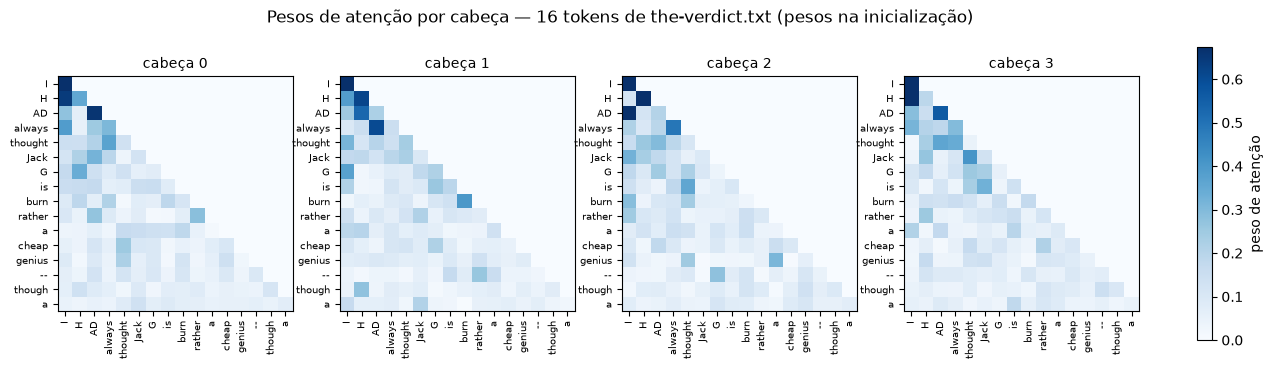

In [21]:
import matplotlib.pyplot as plt

rotulos = dados["tokens"]
media = pesos[0].detach()

fig, eixos = plt.subplots(1, 4, figsize=(15, 3.8))
vmax = float(media[:, 2:, :].max())
for k, ax in enumerate(eixos):
    im = ax.imshow(media[k], cmap="Blues", vmin=0, vmax=vmax)
    ax.set_title(f"cabeça {k}", fontsize=10)
    ax.set_xticks(range(len(rotulos)), rotulos, rotation=90, fontsize=7)
    ax.set_yticks(range(len(rotulos)), rotulos, fontsize=7)
fig.colorbar(im, ax=eixos, fraction=0.02, label="peso de atenção")
fig.suptitle("Pesos de atenção por cabeça — 16 tokens de the-verdict.txt (pesos na inicialização)")
plt.show()

As quatro matrizes são visivelmente diferentes entre si — é o comportamento que justifica ter várias
cabeças. Vale a ressalva: como nada foi treinado, essas diferenças vêm da **inicialização aleatória**
de cada bloco de `Wq`/`Wk`, não de padrões linguísticos aprendidos. Os experimentos completos estão
em [`experiments/sprint03-atencao/`](../experiments/sprint03-atencao/).

---
## 7. Exercícios do capítulo

### Exercício 3.1 — comparando `SelfAttentionV1` e `SelfAttentionV2`

`nn.Linear` guarda a matriz de pesos **transposta**, com forma `(d_out, d_in)`. Transferindo com
`.T`, as duas classes produzem saídas idênticas.

In [22]:
torch.manual_seed(789)
v2 = SelfAttentionV2(3, 2)
v1 = SelfAttentionV1(3, 2)

with torch.no_grad():
    v1.W_query.copy_(v2.W_query.weight.T)
    v1.W_key.copy_(v2.W_key.weight.T)
    v1.W_value.copy_(v2.W_value.weight.T)

print("W_query de V2 tem forma (d_out, d_in):", tuple(v2.W_query.weight.shape))
print("W_query de V1 tem forma (d_in, d_out):", tuple(v1.W_query.shape))
print("saídas idênticas após a transferência:", torch.allclose(v1(entradas), v2(entradas)))

W_query de V2 tem forma (d_out, d_in): (2, 3)
W_query de V1 tem forma (d_in, d_out): (3, 2)
saídas idênticas após a transferência: True


### Exercício 3.2 — vetores de contexto de 2 dimensões

Mantendo `num_heads=2` no `MultiHeadAttentionWrapper`, a saída tem dimensão `d_out × num_heads`.
Para obter 2 dimensões no total, basta `d_out=1` — sem alterar a classe.

In [23]:
torch.manual_seed(123)
mhw_2d = MultiHeadAttentionWrapper(
    d_in=3, d_out=1, context_length=6, dropout=0.0, num_heads=2
).eval()
print("formato da saída:", tuple(mhw_2d(lote).shape), " -> 1 x 2 = 2 dimensões")

formato da saída: (2, 6, 2)  -> 1 x 2 = 2 dimensões


### Exercício 3.3 — dimensões do menor GPT-2

O GPT-2 de 117 milhões de parâmetros usa 12 cabeças, embeddings de 768 dimensões e contexto de 1024
tokens. Nos modelos GPT, `d_in = d_out`.

In [24]:
gpt2 = MultiHeadAttention(
    d_in=768, d_out=768, context_length=1024, dropout=0.0, num_heads=12
)

total = sum(p.numel() for p in gpt2.parameters())
print(f"head_dim   : {gpt2.head_dim}   (768 / 12)")
print(f"parâmetros : {total:,}")
print(f"conferência: 4 x 768 x 768 + 768 (bias da out_proj) = {4 * 768 * 768 + 768:,}")

head_dim   : 64   (768 / 12)
parâmetros : 2,360,064
conferência: 4 x 768 x 768 + 768 (bias da out_proj) = 2,360,064


---
## Resumo da Sprint 3

| Mecanismo | Classe | Pesos treináveis | Escala `1/√d_k` | Máscara causal | Cabeças |
|---|---|:---:|:---:|:---:|:---:|
| Atenção simplificada | `atencao_simples` | não | não | não | 1 |
| Self-attention | `SelfAttentionV1` | sim (`nn.Parameter`) | sim | não | 1 |
| Scaled dot-product | `SelfAttentionV2` | sim (`nn.Linear`) | sim | não | 1 |
| Causal attention | `CausalAttention` | sim | sim | sim | 1 |
| Multi-head (empilhada) | `MultiHeadAttentionWrapper` | sim | sim | sim | *n* |
| Multi-head (eficiente) | `MultiHeadAttention` | sim | sim | sim | *n* |

A `MultiHeadAttention` é a classe que será integrada aos blocos Transformer na **Sprint 4**.

A validação numérica contra os valores publicados no livro está em
[`src/validar_atencao.py`](../src/validar_atencao.py):

```bash
python src/validar_atencao.py
```